<a href="https://colab.research.google.com/github/ngost2002/MATH_AI/blob/main/Code/Gaussian_Orthogonal_Ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
import torch
import math

In [71]:
# Create Gaussian Orthogonal Ensemble Matrix (GOE) with Cij​∼N(0,1/n),Cii​∼N(0,2/n)
n = 1000
Z = torch.zeros(n,n)
A = torch.normal( Z, 1.0) / math.sqrt(n)      #divide sqrt(n) because the eigenvalue will scale with O(sqrt(n))
B = torch.triu(A, diagonal=1)                 #take the upper half along diagonal line (diagonal line not include)
D = math.sqrt(2) * torch.diag(torch.diag(A))  #multiply sqrt(2) because Cii​∼N(0,2/n), along the diagonal line
C = B + torch.transpose(B, 0, 1) + D          # C is GOE matrix

# print(A)
# print(B)
# print(C)
# print(D)

In [72]:
e,v = torch.linalg.eig(A)   #e eigenvalue, v eigenvector
# print(e)

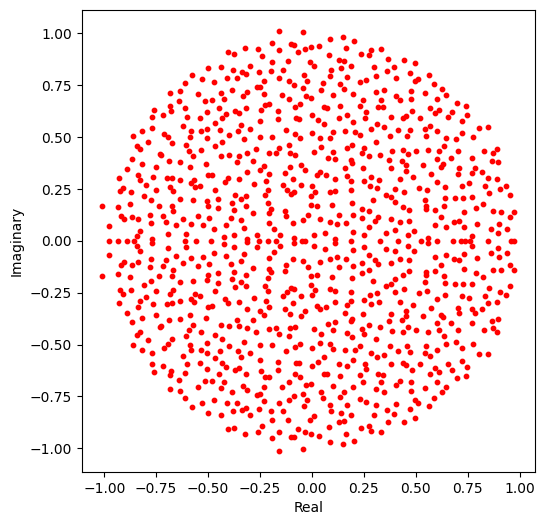

In [73]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(e.real, e.imag, color='red', s=10)

ax.set_aspect('equal', adjustable='box')

ax.set_xlabel('Real')
ax.set_ylabel('Imaginary')

plt.show()


(array([ 53.,  89., 110., 120., 127., 127., 121., 109.,  91.,  53.]),
 array([-2.00016356, -1.60067844, -1.20119321, -0.80170798, -0.40222287,
        -0.00273776,  0.39674759,  0.7962327 ,  1.19571781,  1.59520292,
         1.99468803]),
 <BarContainer object of 10 artists>)

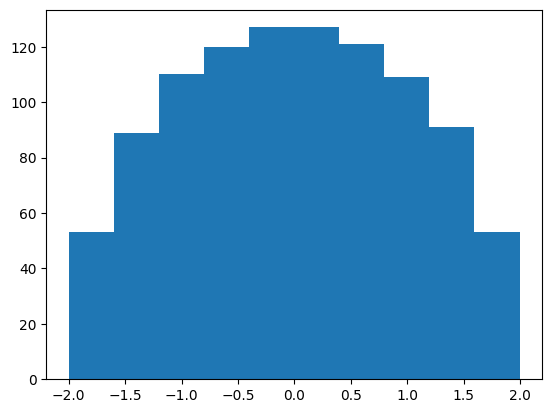

In [74]:
e,v = torch.linalg.eigh(C)
plt.hist(e)

(array([ 69., 163., 178., 180., 131., 105.,  64.,  38.,  20.,  19.,  10.,
          9.,   1.,   3.,   0.,   0.,   3.,   0.,   0.,   0.,   1.,   0.,
          1.,   2.,   1.,   0.,   0.,   0.,   0.,   1.]),
 array([7.96318054e-05, 1.05321407e-03, 2.02679634e-03, 3.00037861e-03,
        3.97396088e-03, 4.94754314e-03, 5.92112541e-03, 6.89470768e-03,
        7.86828995e-03, 8.84187222e-03, 9.81545448e-03, 1.07890368e-02,
        1.17626190e-02, 1.27362013e-02, 1.37097836e-02, 1.46833658e-02,
        1.56569481e-02, 1.66305304e-02, 1.76041126e-02, 1.85776949e-02,
        1.95512772e-02, 2.05248594e-02, 2.14984417e-02, 2.24720240e-02,
        2.34456062e-02, 2.44191885e-02, 2.53927708e-02, 2.63663530e-02,
        2.73399353e-02, 2.83135176e-02, 2.92870998e-02]),
 <BarContainer object of 30 artists>)

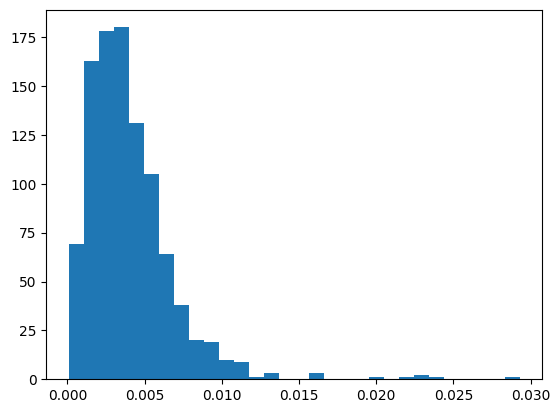

In [75]:
f, I = torch.sort(e.real )
g = torch.diff(f)
plt.hist(g, bins=30)

**Creating Gaussian Unitary Ensemble Matrix**

In [76]:
# Create (GUE) ReCij​,ImCij​∼N(0,1/(2n)), Cii​∼N(0,1/n).
X = torch.randn(n, n)                           #it is the same as torch.normal( Z, 1.0)
Y = torch.randn(n, n)

A = (X + 1j * Y) / math.sqrt(2 * n)             #ReCij​,ImCij​∼N(0,1/(2n))

B = torch.triu(A, diagonal=1)                   #take the upper half along diagonal line (diagonal line not include)

D = torch.diag(torch.randn(n) / math.sqrt(n))   # real number diagonal with Cii​∼N(0,1/n).

G = B + B.conj().T + D

In [77]:
#Eigenvalues and eigenvectors of GUE matrix
eigenvalues, eigenvectors = torch.linalg.eigh(G)

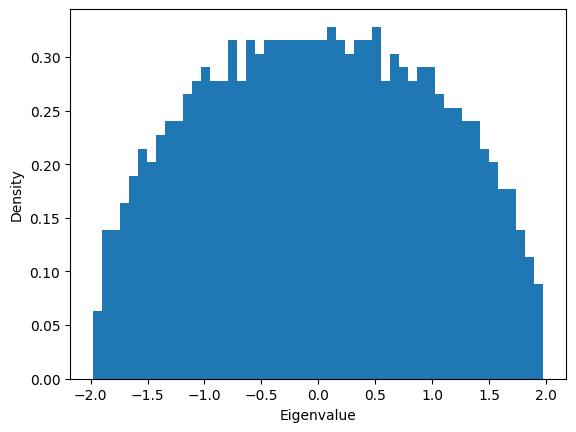

In [78]:
#Plot histogram of eigenvalues of GUE
plt.hist(eigenvalues, bins=50, density=True)
plt.xlabel("Eigenvalue")
plt.ylabel("Density")
plt.show()

(array([ 45.,  98., 180., 192., 171., 113.,  82.,  39.,  25.,  20.,   9.,
          4.,   5.,   5.,   2.,   2.,   2.,   0.,   2.,   0.,   0.,   0.,
          0.,   1.,   0.,   0.,   0.,   0.,   0.,   2.]),
 array([0.00042057, 0.00122529, 0.00203001, 0.00283474, 0.00363946,
        0.00444418, 0.0052489 , 0.00605363, 0.00685835, 0.00766307,
        0.00846779, 0.00927252, 0.01007724, 0.01088196, 0.01168668,
        0.01249141, 0.01329613, 0.01410085, 0.01490557, 0.01571029,
        0.01651502, 0.01731974, 0.01812446, 0.01892918, 0.01973391,
        0.02053863, 0.02134335, 0.02214807, 0.0229528 , 0.02375752,
        0.02456224]),
 <BarContainer object of 30 artists>)

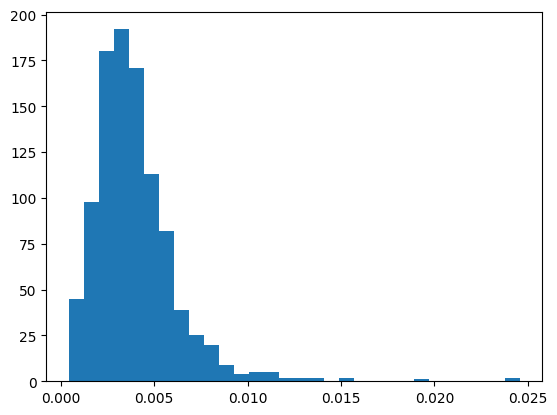

In [82]:
#Plot difference between Eigenvalues
difference, I = torch.sort(eigenvalues)
g = torch.diff(difference)
plt.hist(g, bins=30)